**1. Importing Dataset**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [7]:
df = pd.read_csv('../data/cancer.csv')


**2.Getting Info About Dataset**

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

**3. Dataset Visualization**

<Axes: xlabel='diagnosis'>

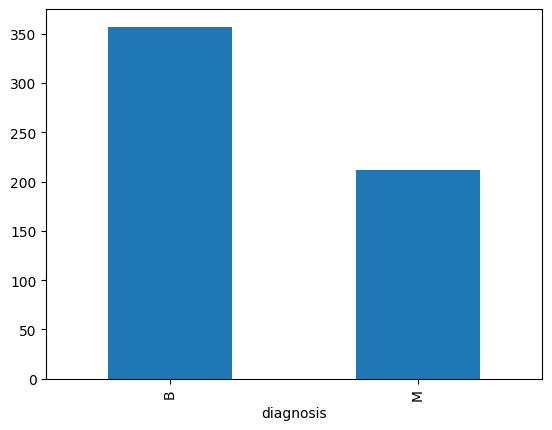

In [8]:
df['diagnosis'].value_counts().plot(kind='bar')


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt


<Axes: xlabel='radius_mean', ylabel='texture_mean'>

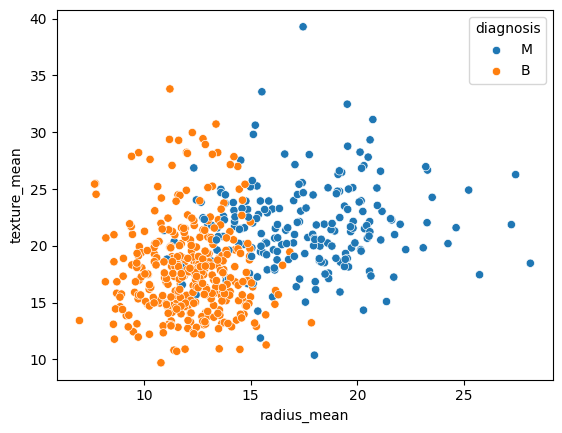

In [12]:
sns.scatterplot(x=df['radius_mean'], y=df['texture_mean'], hue=df['diagnosis'])


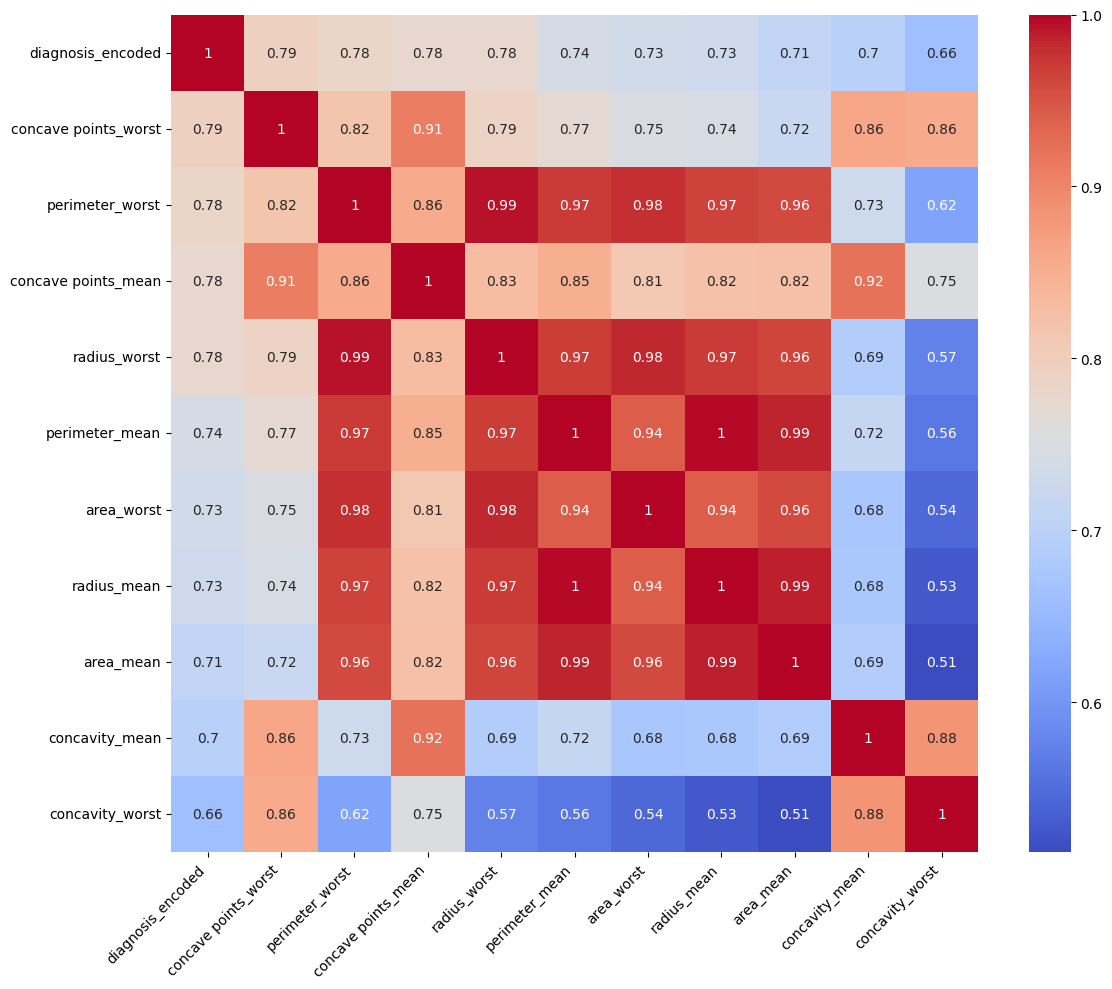

In [17]:
corr = df.select_dtypes(include='number').corr()
top_features = corr['diagnosis_encoded'].abs().sort_values(ascending=False).head(11).index

plt.figure(figsize=(12,10))
sns.heatmap(
    corr.loc[top_features, top_features],
    cmap='coolwarm',
    annot=True
)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**4. Meaning of Naive Bayes Algorithm**

In [24]:
# Data sangat sederhana
data = [
    ("Positive", "Yes"),
    ("Positive", "Yes"),
    ("Negative", "No"),
    ("Positive", "No"),
]

# Hitung prior (P(Yes), P(No))
total = len(data)
P_yes = sum(1 for x in data if x[1] == "Yes") / total
P_no  = sum(1 for x in data if x[1] == "No") / total

# Fitur yang ingin diprediksi
test_value = "Positive"

# Hitung likelihood P(test | class)
P_test_yes = sum(1 for x in data if x[0] == test_value and x[1] == "Yes") / sum(1 for x in data if x[1] == "Yes")
P_test_no  = sum(1 for x in data if x[0] == test_value and x[1] == "No") / sum(1 for x in data if x[1] == "No")

# Hitung posterior P(class | test)
posterior_yes = P_test_yes * P_yes
posterior_no  = P_test_no * P_no

print("P(Yes | Positive) =", posterior_yes)
print("P(No  | Positive) =", posterior_no)

# Prediksi akhir
prediction = "Yes" if posterior_yes > posterior_no else "No"
print("\nPrediksi:", prediction)


P(Yes | Positive) = 0.5
P(No  | Positive) = 0.25

Prediksi: Yes


**5. Naive Bayes with Sklearn**

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Drop kolom yang tidak perlu
df = df.drop(columns=['id', 'Unnamed: 32'])

# Encode diagnosis M=1, B=0
df['diagnosis'] = df['diagnosis'].map({'M':1,'B':0})

# Split data
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = GaussianNB()
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Evaluasi
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        71
           1       1.00      1.00      1.00        43

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114

